<a href="https://colab.research.google.com/github/switlanakostyuk-ctrl/Apollo/blob/main/%22HW_15_2_%D0%9F%D0%B5%D1%80%D0%B5%D0%B2%D1%96%D1%80%D0%BA%D0%B0_%D1%81%D1%82%D0%B0%D1%82%D0%B8c%D1%82%D0%B8%D1%87%D0%BD%D0%B8%D1%85_%D0%B3%D1%96%D0%BF%D0%BE%D1%82%D0%B5%D0%B7_Z_test_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Перевірка статиcтичних гіпотез. Z-test.



0. Зчитайте дані з `data.csv` у змінну data, яка має тип pandas.DataFrame. Ми будемо далі працювати з цією змінною.

In [31]:
import pandas as pd
data = pd.read_csv('data.csv')
print(type(data))
data.head()

<class 'pandas.core.frame.DataFrame'>


,Unnamed: 0,data
0,0,17.499453
1,1,19.662399
2,2,7.182823
3,3,29.841625
4,4,9.239386


Запустіть код нижче. Для коректної робити всіх подальших методів дані мають бути у вигляді одновимірного `numpy.ndarray` вектора та мати розмірність (100,). Така розмірність означає, що дані - одновимірні (колонка), якщо б розмірність була (100, 1), то дані сприймаються методами як двовимірні (таблиця), хоча для нас виглядати можуть так само.

In [32]:
data = data.data.values
data.shape

(100,)

**Завдання 1**. (7 балів)
Зчитані дані - це сума покупок в доларах наших покупців на сайті протягом липня 2025 року.

До цього місяця, ми мали продажі в середньому на чек $20.

Необхідно зʼясувати, чи вийшло у нас статистично значущо **підвищити** середній чек за липень 2025?

Аби дати відповідь - ми проведемо z-test на рівні значущості $\alpha=0.05$ двома способами. В цьому завданні ми будемо виконувати обчислення "вручну" з використанням бібліотек numpy та scipy.stats подібно до прикладу в лекції. Для цього виконайте наступні 7 кроків. Правильне виконання кожного з кроків оцінюється в 1 бал.

1. Запишіть параметри задачі у змінні Python:
    - `sample_mean` - $\bar{x}$, середнє значення в вибірці
    - `population_mean` - $\mu_0$, середнє значення в популяції (тобто те, з яким ми порівнюємо середнє вибіркове значення)
    - `population_std` - $\sigma$, вибіркове стандартне відхилення, яке ми вважаємо, що є рівним ст. відх. популяції, адже маємо достатньо велику вибірку.
    - `sample_size` - $n$, розмір вибірки
    - `alpha` - $\alpha$ рівень значущості
    
    **Увага!** Для обчислення стандартного відхилення маємо скористатись функцією `np.std(your_dataframe, ddof=1)`. Чому так - розбираємо в лекції про t-test.


2. Визначте для цієї задачі:
    - якою є гіпотеза $H_0$
    - якою є альтернативна гіпотеза $H_a$
    - з яким типом тесту ми маємо справу - лівосторонній, правосторонній чи двосторонній.

3. Обчисліть стандартну помилку SE.
4. Розрахуйте z-статистику.
5. Знайдіть критичне z-значення з допомогою бібліотеки stats.
6. Обчисліть p-value з допомогою бібліотеки stats.
7. Прийміть рішення, чи відхиляєте ви гіпотезу $H_0$. Для прийняття рішення зробіть і порівняння z-статистики з критичним значенням, і проаналізуйте p-value.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

In [34]:
sample_mean = np.mean(data)                 # x̄ середнє вибірки
population_mean = 20                        # μ0 з чим порівнювати
population_std = np.std(data, ddof=1)       # σ стандартне відхилення вибірки
sample_size = len(data)                     # n розмір вибірки
alpha = 0.05                                # α рівень значущості

Стандартна помилка (SE) (або стандартне відхилення вибіркового середнього) показує, наскільки в середньому відхиляється вибіркове середнє від справжнього середнього популяції. Чим більша вибірка, тим менша стандартна помилка.

In [35]:
standard_error = population_std / np.sqrt(sample_size)

print("=" * 60)
print("КРОК 3: ОБЧИСЛЕННЯ СТАНДАРТНОЇ ПОМИЛКИ:")
print("=" * 60)
print("Формула: SE = σ / √n")
print(f"SE = {population_std:.3f} / √{sample_size}")
print(f"SE = {population_std:.3f} / {np.sqrt(sample_size):.3f}")
print(f"SE = {standard_error:.3f}")
print(f"\nІнтерпретація: В середньому, вибіркове середнє відхиляється")
print(f"від справжнього середнього на ±{standard_error:.3f} доларів")
print("-" * 60)

КРОК 3: ОБЧИСЛЕННЯ СТАНДАРТНОЇ ПОМИЛКИ:
Формула: SE = σ / √n
SE = 6.254 / √100
SE = 6.254 / 10.000
SE = 0.625

Інтерпретація: В середньому, вибіркове середнє відхиляється
від справжнього середнього на ±0.625 доларів
------------------------------------------------------------


Z-статистика показує, на скільки стандартних помилок наше вибіркове середнє відхиляється від гіпотетичного середнього популяції. Це стандартизована міра відстані.

In [38]:
z_statistic = (sample_mean - population_mean) / standard_error

print("=" * 60)
print("КРОК 4: РОЗРАХУНОК Z-СТАТИСТИКИ:")
print("=" * 60)
print("Формула: z = (x̄ - μ₀) / SE")
print(f"z = ({sample_mean:.3f} - {population_mean}) / {standard_error:.3f}")
print(f"z = {sample_mean - population_mean:.3f} / {standard_error:.3f}")
print(f"z = {z_statistic:.3f}")
print()


print("Інтерпретація:")
print(f"Вибіркове середнє відхиляється на {z_statistic:.3f} стандартних")
print("помилок від гіпотетичного середнього популяції.")
print()

КРОК 4: РОЗРАХУНОК Z-СТАТИСТИКИ:
Формула: z = (x̄ - μ₀) / SE
z = (19.378 - 20) / 0.625
z = -0.622 / 0.625
z = -0.995

Інтерпретація:
Вибіркове середнє відхиляється на -0.995 стандартних
помилок від гіпотетичного середнього популяції.



Критичне значення (z-значення) — це межа, після якої ми вважаємо результат "занадто екстремальним", щоб бути випадковим. Для рівня значущості 5% і правостороннього тесту, критичне значення відсікає праві 5% розподілу.

Як обчислити критичне z-значення в Python?
Для обчислення критичного значення використовуємо функцію stats.norm.ppf():

In [39]:
z_critical = stats.norm.ppf(1 - alpha)

Що робить ця функція:

ppf (Percent Point Function) - це обернена функція до CDF (Cumulative distribution function)
PPF відповідає на питання: "Яке z-значення відсікає задану площу зліва?"
Для правостороннього тесту з α=0.05 нам потрібна точка, що відсікає 95% зліва
Тому передаємо 1 - alpha = 0.95

In [40]:
z_critical = stats.norm.ppf(1 - alpha)

print("=" * 60)
print("КРОК 5: КРИТИЧНЕ ЗНАЧЕННЯ:")
print("=" * 60)
print(f"Для рівня значущості α = {alpha} (правосторонній тест)")
print(f"Критичне z-значення = {z_critical:.3f}")
print()
print("Що це означає?")
print(f"Якщо z-статистика > {z_critical:.3f}, то результат настільки")
print("незвичайний, що ми не віримо у випадковість за гіпотезою Н0.")
print(f"Ймовірність отримати z > {z_critical:.3f} випадково = {alpha*100}%")
print("-" * 60)

КРОК 5: КРИТИЧНЕ ЗНАЧЕННЯ:
Для рівня значущості α = 0.05 (правосторонній тест)
Критичне z-значення = 1.645

Що це означає?
Якщо z-статистика > 1.645, то результат настільки
незвичайний, що ми не віримо у випадковість за гіпотезою Н0.
Ймовірність отримати z > 1.645 випадково = 5.0%
------------------------------------------------------------


P-value — це ймовірність отримати такий або більш екстремальний результат, якщо нульова гіпотеза правдива. Це міра, наскільки за умови правдивості Н0 гіпотези наші дані є "дивними".

Як обчислити p-value в Python?
Для обчислення p-value використовуємо функцію stats.norm.cdf():

In [41]:
p_value = 1 - stats.norm.cdf(z_statistic)

print("КРОК 6: ОБЧИСЛЕННЯ P-VALUE:")
print("=" * 60)
print(f"p-value = {p_value:.4f}")
print()
print("Що це означає?")
print(f"p-value — це ймовірність отримати такий (або ще більший) середній чек,")
print(f"якщо насправді середнє в популяції все ще залишається {population_mean}$.")
print(f"Якщо p-value < {alpha}, ми кажемо, що це занадто малоймовірно для випадковості.")
print("-" * 60)

КРОК 6: ОБЧИСЛЕННЯ P-VALUE:
p-value = 0.8402

Що це означає?
p-value — це ймовірність отримати такий (або ще більший) середній чек,
якщо насправді середнє в популяції все ще залишається 20$.
Якщо p-value < 0.05, ми кажемо, що це занадто малоймовірно для випадковості.
------------------------------------------------------------


Приймаємо рішення
Два способи прийняття рішення:
Метод 1: Порівняння z-статистики з критичним значенням

In [42]:
print("=" * 60)
print("МЕТОД 1: Порівняння z-статистики з критичним значенням")
print("=" * 60)
print(f"z-статистика = {z_statistic:.3f}")
print(f"Критичне значення = {z_critical:.3f}")
print(f"Порівняння: {z_statistic:.3f} {'>' if z_statistic > z_critical else '≤'} {z_critical:.3f}")

if z_statistic > z_critical:
    print("Висновок: z-статистика ПЕРЕВИЩУЄ критичне значення")
    decision1 = "ВІДХИЛЯЄМО H₀"
else:
    print("Висновок: z-статистика НЕ перевищує критичне значення")
    decision1 = "НЕ ВІДХИЛЯЄМО H₀"

print(f"Рішення: {decision1}")

МЕТОД 1: Порівняння z-статистики з критичним значенням
z-статистика = -0.995
Критичне значення = 1.645
Порівняння: -0.995 ≤ 1.645
Висновок: z-статистика НЕ перевищує критичне значення
Рішення: НЕ ВІДХИЛЯЄМО H₀


Метод 2: Порівняння p-value з рівнем значущості (ЧАСТІШЕ ВИКОРИСТОВУЄТЬСЯ)



In [43]:
print("\n" + "=" * 60)
print("МЕТОД 2: Порівняння p-value з рівнем значущості")
print("=" * 60)
print()
print(f"p-value = {p_value:.6f}")
print(f"Рівень значущості α = {alpha}")
print(f"Порівняння: {p_value:.6f} {'<' if p_value < alpha else '≥'} {alpha}")

if p_value < alpha:
    print("Висновок: p-value МЕНШЕ за рівень значущості")
    decision2 = "ВІДХИЛЯЄМО H₀"
else:
    print("Висновок: p-value НЕ менше за рівень значущості")
    decision2 = "НЕ ВІДХИЛЯЄМО H₀"

print(f"Рішення: {decision2}")


МЕТОД 2: Порівняння p-value з рівнем значущості

p-value = 0.840216
Рівень значущості α = 0.05
Порівняння: 0.840216 ≥ 0.05
Висновок: p-value НЕ менше за рівень значущості
Рішення: НЕ ВІДХИЛЯЄМО H₀


Фінальний висновок:

In [44]:
print("\n" + "=" * 60)
print("ФІНАЛЬНИЙ ВИСНОВОК:")
print("=" * 60)

if decision2 == "ВІДХИЛЯЄМО H₀":
    print("✅ Гіпотеза про підвищення чека ПІДТВЕРДЖУЄТЬСЯ!")
    print("   Нам дійсно вдалося статистично значущо підвищити середній чек у липні")
    print(f"   Середній чек липневих покупців (${sample_mean:.2f}) статистично значуще")
    print(f"   перевищує попередній середній чек (${population_mean})")
else:
    print("❌ Гіпотеза про підвищення чека НЕ ПІДТВЕРДЖУЄТЬСЯ")
    print("   Немає достатніх статистичних доказів, що середній чек")
    print(f"   у липні став вищим за попередній показник у ${population_mean}")
print("=" * 60)


ФІНАЛЬНИЙ ВИСНОВОК:
❌ Гіпотеза про підвищення чека НЕ ПІДТВЕРДЖУЄТЬСЯ
   Немає достатніх статистичних доказів, що середній чек
   у липні став вищим за попередній показник у $20


ВІЗУАЛІЗАЦІЯ

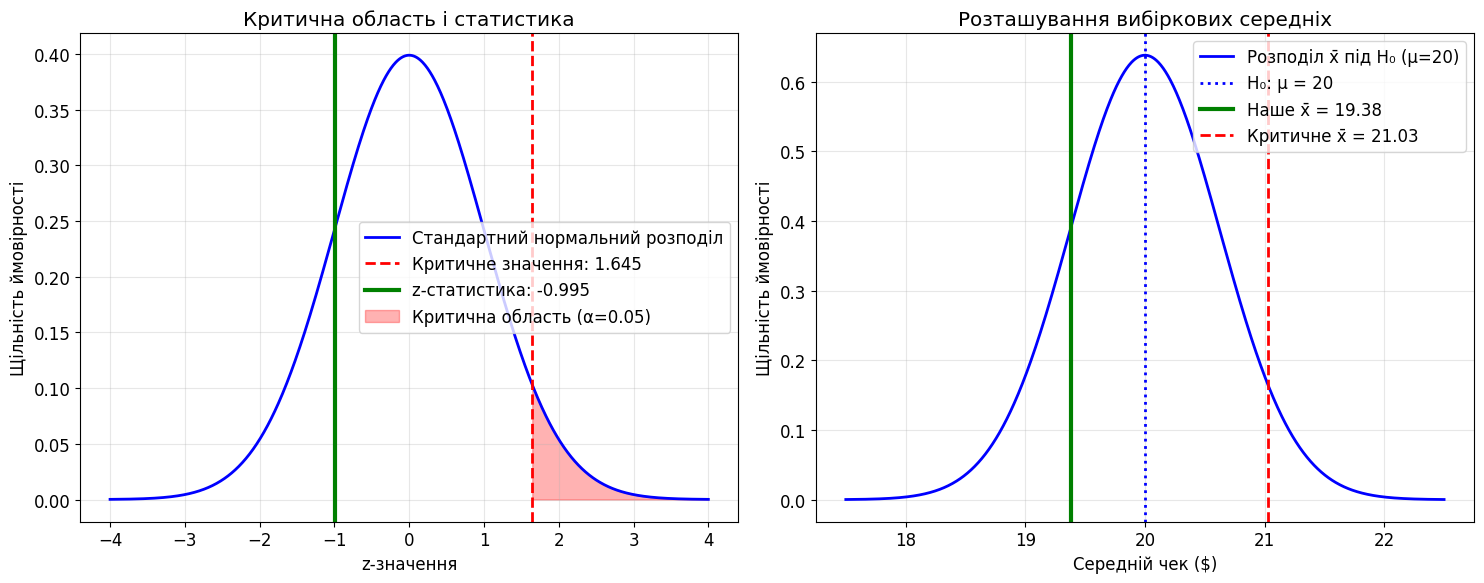

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

# ГРАФІК 1
ax1 = axes[0]
ax1.plot(x, y, 'b-', linewidth=2, label='Стандартний нормальний розподіл')

# Критичне значення
ax1.axvline(z_critical, color='red', linestyle='--', linewidth=2,
            label=f'Критичне значення: {z_critical:.3f}')

# Z-статистика
ax1.axvline(z_statistic, color='green', linestyle='-', linewidth=3,
            label=f'z-статистика: {z_statistic:.3f}')

# праворуч зафарбувати, бо тест правосторонній
x_crit = x[x >= z_critical]
y_crit = stats.norm.pdf(x_crit, 0, 1)
ax1.fill_between(x_crit, y_crit, alpha=0.3, color='red',
                  label=f'Критична область (α={alpha})')

ax1.set_xlabel('z-значення')
ax1.set_ylabel('Щільність ймовірності')
ax1.set_title('Критична область і статистика')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ГРАФІК 2
ax2 = axes[1]
# Діапазон для графіка в доларах
x_means = np.linspace(population_mean - 4*standard_error,
                      population_mean + 4*standard_error, 1000)
y_means = stats.norm.pdf(x_means, population_mean, standard_error)

ax2.plot(x_means, y_means, 'b-', linewidth=2,
         label=f'Розподіл x̄ під H₀ (μ={population_mean})')

# Гіпотетичне середнє
ax2.axvline(population_mean, color='blue', linestyle=':', linewidth=2,
            label=f'H₀: μ = {population_mean}')

# вибіркове середнє
ax2.axvline(sample_mean, color='green', linestyle='-', linewidth=3,
            label=f'Наше x̄ = {sample_mean:.2f}')

# Критичне значення в доларах
critical_val_money = population_mean + z_critical * standard_error
ax2.axvline(critical_val_money, color='red', linestyle='--', linewidth=2,
            label=f'Критичне x̄ = {critical_val_money:.2f}')

ax2.set_xlabel('Середній чек ($)')
ax2.set_ylabel('Щільність ймовірності')
ax2.set_title('Розташування вибіркових середніх')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Завдання 2.** (3 бали)
Виконайте обчислення z-test з використанням бібліотеки statsmodels.

Отримайте z-статистику та р-значення.

Виведіть p-значення та зробіть висновок, чи ми маємо достатньо доказів, аби стверджувати, що середній чек зріс.

Чи зійшлись значення z-статистику та р-значення в цьому завданні з попередніми обчисленнями?

In [45]:
from statsmodels.stats import weightstats as stests

print("=" * 60)
print("ЗАВДАННЯ 2: ВИКОРИСТАННЯ STATSMODELS ДЛЯ Z-ТЕСТУ:")
print("=" * 60)

ЗАВДАННЯ 2: ВИКОРИСТАННЯ STATSMODELS ДЛЯ Z-ТЕСТУ:


In [46]:
z_stat_sm, p_val_sm = stests.ztest(x1=data,
                                   value=population_mean,
                                   alternative='larger')

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТИ Z-ТЕСТУ (STATSMODELS):")
print("=" * 60)
print(f"  Z-статистика: {z_stat_sm:.3f}")
print(f"  P-value: {p_val_sm:.6f}")
print()


РЕЗУЛЬТАТИ Z-ТЕСТУ (STATSMODELS):
  Z-статистика: -0.995
  P-value: 0.840216



ІНТЕРПРЕТАЦІЯ

In [47]:
if p_val_sm < alpha:
    print(f"✅ ВІДХИЛЯЄМО H₀")
    print(f"   p-value ({p_val_sm:.6f}) < α ({alpha})")
    print("   Висновок: Середній чек за липень 2025 року статистично значущо ПІДВИЩИВСЯ.")
else:
    print(f"❌ НЕ ВІДХИЛЯЄМО H₀")
    print(f"   p-value ({p_val_sm:.6f}) ≥ α ({alpha})")
    print("   Висновок: Немає достатніх доказів, що середній чек зріс не випадково.")

❌ НЕ ВІДХИЛЯЄМО H₀
   p-value (0.840216) ≥ α (0.05)
   Висновок: Немає достатніх доказів, що середній чек зріс не випадково.


In [48]:
print("\n" + "=" * 60)
print("ПОРІВНЯННЯ З РУЧНИМИ РОЗРАХУНКАМИ:")
print("=" * 60)
print(f"Z-статистика:")
print(f"  Ручний розрахунок: {z_statistic:.3f}")
print(f"  Statsmodels:      {z_stat_sm:.3f}")
print(f"  Різниця:                       {abs(z_statistic - z_stat_sm):.6f}")
print()
print(f"P-value:")
print(f"  Ручний розрахунок: {p_value:.6f}")
print(f"  Statsmodels:      {p_val_sm:.6f}")

if abs(z_statistic - z_stat_sm) < 1e-5:
    print("\n✅ ВИСНОВОК: Значення повністю зійшлися!")
    print("Це підтверджує правильність обох методів розрахунку.")
else:
    print("\n⚠️ Примітка: Невелика різниця може бути зумовлена")
    print("точністю округлення в бібліотеках.")


ПОРІВНЯННЯ З РУЧНИМИ РОЗРАХУНКАМИ:
Z-статистика:
  Ручний розрахунок: -0.995
  Statsmodels:      -0.995
  Різниця:                       0.000000

P-value:
  Ручний розрахунок: 0.840216
  Statsmodels:      0.840216

✅ ВИСНОВОК: Значення повністю зійшлися!
Це підтверджує правильність обох методів розрахунку.


ВІДПОВІДЬ НА ЗАПИТАНЯ

Так, зійшлися.
Люди в липні витрачали трохи менше, ніж зазвичай. Через це Z-статистика від’ємна -0.995, а щоб чек зріс, число мало бути більшим за 1.645
Результат відноситься до нульової гіпотези Н0.